### CNN Image
### Yilin Luo

### Table of Contents

* [1: Data Preparation](#Section_1)
    * [Load and Preview Raw Data](#Section_11)
    * [Split into train and test (80/20 split)](#Section_12)
    * [Visualization some images from Train Set](#Section_13)
    * [Creating Dataloaders](#Section_14)
  
* [2: Build and Train CNN](#Section_2)
    * [Define the Brain Tumor Model](#Section_21)
    * [Define Architecture For CNN_TUMOR Model](#Section_22)
    * [Define the Model Training](#Section_23)
    * [Define the Loss Function](#Section_24)
    * [Define the Optimiser](#Section_25)
    * [Train Model](#Section_26)
    * [Training Function](#Section_27)
    * [Training Process](#Section_28)
    
* [3: Evaluate the Model](#Section_3)
    * [Evaluation Metric Visualization](#Section_31)
    * [Confusion Matrix](#Section_32)
    * [Display Correct & Incorrect Predictions](#Section_33)
    * [Save Model](#Section_34)
    
* [4. Reflection (Q1 - Q4)](#Section_4)

In [4]:
#!pip install split-folders
#!pip install torch-summary
#!pip install seaborn torch tqdm torchvision  scikit-learn
#!pip install ipywidgets --upgrade

In [3]:
# Import essential libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style='darkgrid')
import copy # A module that provides functions for creating copies of objects, useful for avoiding unintended modifications to variables.
import os # A module that provides a way to interact with the operating system, allowing for tasks such as file and directory manipulation.
import torch
from PIL import Image # A module from the Python Imaging Library (PIL) that provides functionality for opening, manipulating, and saving various image file formats.
from torch.utils.data import Dataset # A PyTorch class that represents a dataset and provides an interface for accessing and processing the data during training.
import torchvision
import torchvision.transforms as transforms # A module from the torchvision library that provides common image transformations, such as resizing, cropping, and normalization.
from torch.utils.data import random_split # A function from PyTorch that allows for randomly splitting a dataset into training and validation subsets.
from torch.optim.lr_scheduler import ReduceLROnPlateau # A PyTorch scheduler that adjusts the learning rate during training based on a specified metric, reducing it when the metric plateaus.
import torch.nn as nn # A module in PyTorch that provides classes for defining and building neural networks.
from torchvision import utils # A module from torchvision that contains utility functions for working with images, such as saving and visualizing them.
from torchvision.datasets import ImageFolder
import splitfolders
from torchsummary import summary
import torch.nn.functional as F
import pathlib
from sklearn.metrics import confusion_matrix, classification_report
import itertools # This import statement imports the itertools module, which provides functions for efficient looping and combining of iterables. It can be used for tasks such as generating combinations or permutations of elements.
from tqdm.notebook import trange, tqdm # These functions allow for the creation of progress bars to track the progress of loops or tasks.
from torch import optim
import warnings
warnings.filterwarnings('ignore')

### 1. Data Preparation <a class="anchor" id="Section_1"></a>

### Load dataset <a class="anchor" id="Section_11"></a>

In [4]:
labels_df = pd.read_csv('/Users/yilin/Downloads/brain_tumor_metadata.csv')
print(labels_df.shape)
labels_df

(4600, 6)


,Unnamed: 0,image,class,format,mode,shape
0,0,Cancer (1).jpg,tumor,JPEG,RGB,"(512, 512, 3)"
1,1,Cancer (1).png,tumor,PNG,L,"(300, 240)"
2,2,Cancer (1).tif,tumor,TIFF,RGB,"(256, 256, 3)"
3,3,Cancer (10).jpg,tumor,JPEG,RGB,"(512, 512, 3)"
4,4,Cancer (10).tif,tumor,TIFF,RGB,"(256, 256, 3)"
...,...,...,...,...,...,...
4595,4595,Not Cancer (995).jpg,normal,JPEG,RGB,"(168, 300, 3)"
4596,4596,Not Cancer (996).jpg,normal,JPEG,RGB,"(509, 452, 3)"
4597,4597,Not Cancer (997).jpg,normal,JPEG,RGB,"(197, 177, 3)"
4598,4598,Not Cancer (998).jpg,normal,JPEG,RGB,"(217, 232, 3)"


In [5]:
labels_df.head()

,Unnamed: 0,image,class,format,mode,shape
0,0,Cancer (1).jpg,tumor,JPEG,RGB,"(512, 512, 3)"
1,1,Cancer (1).png,tumor,PNG,L,"(300, 240)"
2,2,Cancer (1).tif,tumor,TIFF,RGB,"(256, 256, 3)"
3,3,Cancer (10).jpg,tumor,JPEG,RGB,"(512, 512, 3)"
4,4,Cancer (10).tif,tumor,TIFF,RGB,"(256, 256, 3)"


In [6]:
os.listdir('/Users/yilin/Downloads/Brain Tumor Data Set/Brain Tumor Data Set')

['.DS_Store', 'Healthy', 'Brain Tumor']

### Split into train and test (80/20 split) <a class="anchor" id="Section_12"></a>

In [7]:
# Dataset Path
data_dir = '/Users/yilin/Downloads/Brain Tumor Data Set/Brain Tumor Data Set'
data_dir = pathlib.Path(data_dir)

# Splitting dataset to train_set, val_set and test_set
splitfolders.ratio(data_dir, output='/Users/yilin/Downloads/brain', seed=20, ratio=(0.8, 0.2))

Copying files: 4600 files [00:01, 2851.82 files/s]


In [8]:
# New dataset path
data_dir = '/Users/yilin/Downloads/brain'
data_dir = pathlib.Path(data_dir)

We use transforms in torchvision.

In [9]:
# define transformation
transform = transforms.Compose(
    [
        transforms.Resize((256,256)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224, 0.225])
   ]
)

In [10]:
# Define an object of the custom dataset for the train and validation.
train_set = torchvision.datasets.ImageFolder(data_dir.joinpath("train"), transform=transform) 
train_set.transform
val_set = torchvision.datasets.ImageFolder(data_dir.joinpath("val"), transform=transform)
val_set.transform

Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

### Visualization some images from Train Set <a class="anchor" id="Section_13"></a>

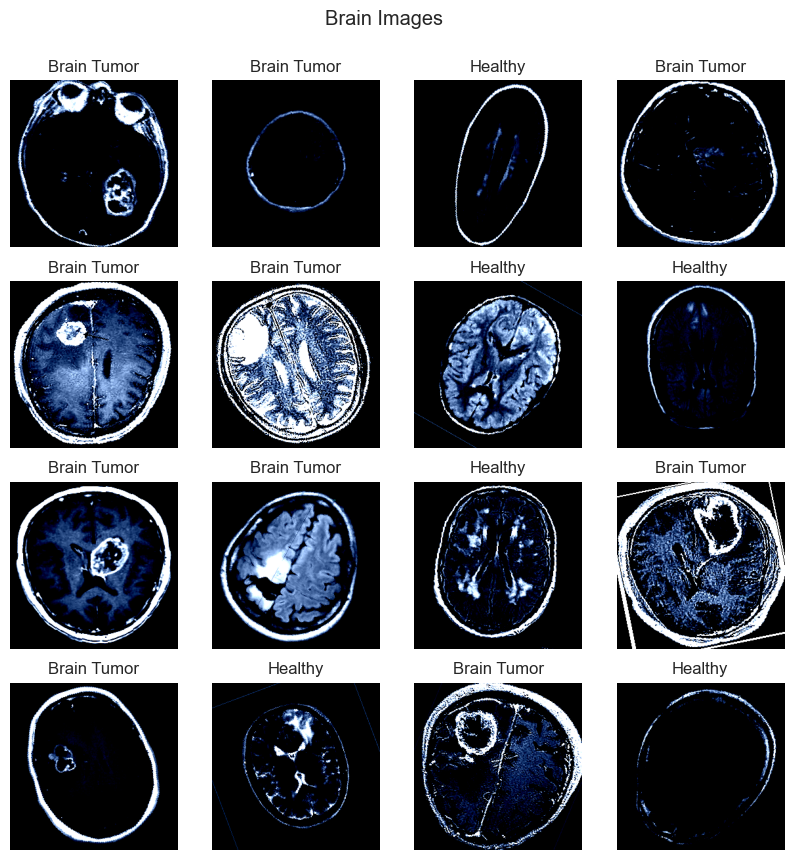

In [11]:
CLA_label = {
    0 : 'Brain Tumor',
    1 : 'Healthy'
} 
figure = plt.figure(figsize=(10, 10))
cols, rows = 4, 4
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_set), size=(1,)).item()
    img, label = train_set[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(CLA_label[label])
    plt.axis("off")
    img_np = img.numpy().transpose((1, 2, 0))
    # Clip pixel values to [0, 1]
    img_valid_range = np.clip(img_np, 0, 1)
    plt.imshow(img_valid_range)
    plt.suptitle('Brain Images', y=0.95)
plt.show()

### Creating Dataloaders <a class="anchor" id="Section_14"></a>

In [12]:
# import and load train, validation
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_set, batch_size = batch_size, shuffle = True, num_workers = 2)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = batch_size, shuffle = True, num_workers = 2)

In [13]:
# Print shape for training data and validation data
for key, value in {'Training data': train_loader, "Validation data": val_loader}.items():
    for X, y in value:
        print(f"{key}:")
        print(f"Shape of X : {X.shape}")
        print(f"Shape of y: {y.shape} {y.dtype}\n")
        break

Training data:
Shape of X : torch.Size([64, 3, 256, 256])
Shape of y: torch.Size([64]) torch.int64

Validation data:
Shape of X : torch.Size([64, 3, 256, 256])
Shape of y: torch.Size([64]) torch.int64



### 2. Build and Train CNN <a class="anchor" id="Section_2"></a>

### Define the Brain Tumor Model <a class="anchor" id="Section_21"></a>

In [14]:
'''This function can be useful in determining the output size of a convolutional layer in a neural network,
given the input dimensions and the convolutional layer's parameters.'''

def findConv2dOutShape(hin,win,conv,pool=2):
    # get conv arguments
    kernel_size = conv.kernel_size
    stride=conv.stride
    padding=conv.padding
    dilation=conv.dilation

    hout=np.floor((hin+2*padding[0]-dilation[0]*(kernel_size[0]-1)-1)/stride[0]+1)
    wout=np.floor((win+2*padding[1]-dilation[1]*(kernel_size[1]-1)-1)/stride[1]+1)

    if pool:
        hout/=pool
        wout/=pool
    return int(hout),int(wout)

### Define Architecture For CNN_TUMOR Model <a class="anchor" id="Section_22"></a>

In [15]:
# Define Architecture For CNN_TUMOR Model
class CNN_TUMOR(nn.Module):
    
    # Network Initialisation
    def __init__(self, params):
        
        super(CNN_TUMOR, self).__init__()
    
        Cin,Hin,Win = params["shape_in"]
        init_f = params["initial_filters"] 
        num_fc1 = params["num_fc1"]  
        num_classes = params["num_classes"] 
        self.dropout_rate = params["dropout_rate"] 
        
        # Convolution Layers
        self.conv1 = nn.Conv2d(Cin, init_f, kernel_size=3)
        h,w=findConv2dOutShape(Hin,Win,self.conv1)
        self.conv2 = nn.Conv2d(init_f, 2*init_f, kernel_size=3)
        h,w=findConv2dOutShape(h,w,self.conv2)
        self.conv3 = nn.Conv2d(2*init_f, 4*init_f, kernel_size=3)
        h,w=findConv2dOutShape(h,w,self.conv3)
        self.conv4 = nn.Conv2d(4*init_f, 8*init_f, kernel_size=3)
        h,w=findConv2dOutShape(h,w,self.conv4)
        
        # compute the flatten size
        self.num_flatten=h*w*8*init_f
        self.fc1 = nn.Linear(self.num_flatten, num_fc1)
        self.fc2 = nn.Linear(num_fc1, num_classes)

    def forward(self,X):
        
        # Convolution & Pool Layers
        X = F.relu(self.conv1(X)); 
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv3(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv4(X))
        X = F.max_pool2d(X, 2, 2)
        X = X.view(-1, self.num_flatten)
        X = F.relu(self.fc1(X))
        X = F.dropout(X, self.dropout_rate)
        X = self.fc2(X)
        return F.log_softmax(X, dim=1)

### Define the Model Training <a class="anchor" id="Section_23"></a>

- The Hyperparameters for model training
- The loss function
- The optimiser

In [16]:
params_model={
        "shape_in": (3,256,256), 
        "initial_filters": 8,    
        "num_fc1": 100,
        "dropout_rate": 0.25,
        "num_classes": 2}

# Create instantiation of Network class
cnn_model = CNN_TUMOR(params_model)

# define computation hardware approach (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = cnn_model.to(device)

In [18]:
# Model Summary for CNN Model
summary(cnn_model, input_size=(3, 256, 256),device=device.type)

Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            224
├─Conv2d: 1-2                            1,168
├─Conv2d: 1-3                            4,640
├─Conv2d: 1-4                            18,496
├─Linear: 1-5                            1,254,500
├─Linear: 1-6                            202
Total params: 1,279,230
Trainable params: 1,279,230
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            224
├─Conv2d: 1-2                            1,168
├─Conv2d: 1-3                            4,640
├─Conv2d: 1-4                            18,496
├─Linear: 1-5                            1,254,500
├─Linear: 1-6                            202
Total params: 1,279,230
Trainable params: 1,279,230
Non-trainable params: 0

### Define the Loss Function <a class="anchor" id="Section_24"></a>

In [19]:
loss_func = nn.NLLLoss(reduction="sum")

### Define the Optimiser <a class="anchor" id="Section_25"></a>

In [20]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

opt = Adam(model.parameters(), lr=3e-4)
optimizer = Adam(model.parameters(), lr=3e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10) #, verbose=True)

In [23]:
import torch.optim.lr_scheduler as lrsched
print(lrsched.ReduceLROnPlateau.__module__)

torch.optim.lr_scheduler


### Train Model <a class="anchor" id="Section_26"></a>

In [21]:
# Function to get the learning rate
def get_lr(opt):
    for param_group in opt.param_groups:
        return param_group['lr']

# Function to compute the loss value per batch of data
def loss_batch(loss_func, output, target, opt=None):
    
    loss = loss_func(output, target) # get loss
    pred = output.argmax(dim=1, keepdim=True) # Get Output Class
    metric_b=pred.eq(target.view_as(pred)).sum().item() # get performance metric
    
    if opt is not None:
        opt.zero_grad()
        loss.backward()
        opt.step()

    return loss.item(), metric_b

# Compute the loss value & performance metric for the entire dataset (epoch)
def loss_epoch(model,loss_func,dataset_dl,opt=None):
    
    run_loss=0.0 
    t_metric=0.0
    len_data=len(dataset_dl.dataset)

    # internal loop over dataset
    for xb, yb in dataset_dl:
        # move batch to device
        xb=xb.to(device)
        yb=yb.to(device)
        output=model(xb) # get model output
        loss_b,metric_b=loss_batch(loss_func, output, yb, opt) # get loss per batch
        run_loss+=loss_b        # update running loss

        if metric_b is not None: # update running metric
            t_metric+=metric_b    
    
    loss=run_loss/float(len_data)  # average loss value
    metric=t_metric/float(len_data) # average metric value
    
    return loss, metric

### Training Function <a class="anchor" id="Section_27"></a>

In [22]:
def Train_Val(model, params,verbose=False):
    
    # Get the parameters
    epochs=params["epochs"]
    loss_func=params["f_loss"]
    opt=params["optimiser"]
    train_dl=params["train"]
    val_dl=params["val"]
    lr_scheduler=params["lr_change"]
    weight_path=params["weight_path"]
    
    # history of loss values in each epoch
    loss_history={"train": [],"val": []} 
    # histroy of metric values in each epoch
    metric_history={"train": [],"val": []} 
    # a deep copy of weights for the best performing model
    best_model_wts = copy.deepcopy(model.state_dict()) 
    # initialize best loss to a large value
    best_loss=float('inf') 

# Train Model n_epochs (the progress of training by printing the epoch number and the associated learning rate. It can be helpful for debugging, monitoring the learning rate schedule, or gaining insights into the training process.) 
    
    for epoch in tqdm(range(epochs)):
        
        # Get the Learning Rate
        current_lr=get_lr(opt)
        if(verbose):
            print('Epoch {}/{}, current lr={}'.format(epoch, epochs - 1, current_lr))

        
# Train Model Process

        
        model.train()
        train_loss, train_metric = loss_epoch(model,loss_func,train_dl,opt)

        # collect losses
        loss_history["train"].append(train_loss)
        metric_history["train"].append(train_metric)
        

# Evaluate Model Process

        
        model.eval()
        with torch.no_grad():
            val_loss, val_metric = loss_epoch(model,loss_func,val_dl)
        
        # store best model
        if(val_loss < best_loss):
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            
            # store weights into a local file
            torch.save(model.state_dict(), weight_path)
            if(verbose):
                print("Copied best model weights!")
        
        # collect loss and metric for validation dataset
        loss_history["val"].append(val_loss)
        metric_history["val"].append(val_metric)
        
        # learning rate schedule
        lr_scheduler.step(val_loss)
        if current_lr != get_lr(opt):
            if(verbose):
                print("Loading best model weights!")
            model.load_state_dict(best_model_wts) 

        if(verbose):
            print(f"train loss: {train_loss:.6f}, dev loss: {val_loss:.6f}, accuracy: {100*val_metric:.2f}")
            print("-"*10) 

    # load best model weights
    model.load_state_dict(best_model_wts)
        
    return model, loss_history, metric_history

### Training Process <a class="anchor" id="Section_28"></a>

In [24]:
# Define various parameters used for training and evaluation of a cnn_model

params_train={
 "train": train_loader,"val": val_loader,
 "epochs": 60,
 "optimiser": optim.Adam(cnn_model.parameters(),lr=3e-4),
 "lr_change": ReduceLROnPlateau(opt,
                                mode='min',
                                factor=0.5,
                                patience=20),
#                                verbose=0),
 "f_loss": nn.NLLLoss(reduction="sum"),
 "weight_path": "weights.pt",
}

# train and validate the model
cnn_model,loss_hist,metric_hist = Train_Val(cnn_model,params_train)

  0%|          | 0/60 [00:00<?, ?it/s]

### 3. Evaluate the Model <a class="anchor" id="Section_3"></a>

### Evaluation Metric Visualization <a class="anchor" id="Section_31"></a>

<Axes: >

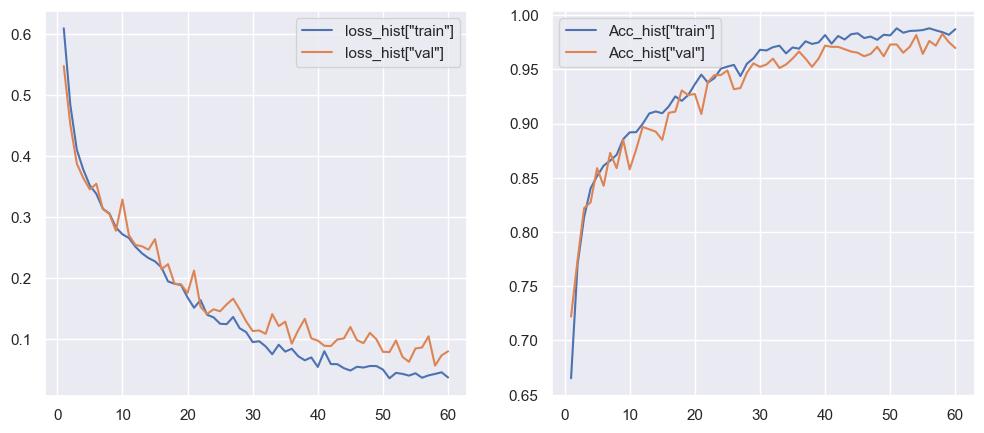

In [25]:
# Convergence History Plot
epochs=params_train["epochs"]
fig,ax = plt.subplots(1,2,figsize=(12,5))

sns.lineplot(x=[*range(1,epochs+1)],y=loss_hist["train"],ax=ax[0],label='loss_hist["train"]')
sns.lineplot(x=[*range(1,epochs+1)],y=loss_hist["val"],ax=ax[0],label='loss_hist["val"]')
sns.lineplot(x=[*range(1,epochs+1)],y=metric_hist["train"],ax=ax[1],label='Acc_hist["train"]')
sns.lineplot(x=[*range(1,epochs+1)],y=metric_hist["val"],ax=ax[1],label='Acc_hist["val"]')

**Finding:**

The evaluation metric visualization shows that the CNN model demonstrated strong learning and generalization performance over the 60 training epochs. The training and validation loss curves both declined steadily, with the training loss dropping below 0.05 and the validation loss stabilizing after around epoch 40. This indicates that the model was able to minimize error without significant overfitting. Similarly, the accuracy curves show a consistent improvement, with training accuracy approaching 99% and validation accuracy reaching around 97% by the end of training. The close alignment between training and validation metrics suggests that the model maintained generalization across the dataset.

Key observations include:
- A smooth and continuous decline in both training and validation loss.
- Validation loss remained stable after epoch 40, suggesting effective early convergence.
- High accuracy was achieved on both training and validation sets, with minimal divergence between them.

### Confusion Matrix <a class="anchor" id="Section_32"></a>

In [26]:
# define function For Classification Report
def Ture_and_Pred(val_loader, model):
    i = 0
    y_true = []
    y_pred = []
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.numpy()
        outputs = model(images)
        _, pred = torch.max(outputs.data, 1)
        pred = pred.detach().cpu().numpy()
        
        y_true = np.append(y_true, labels)
        y_pred = np.append(y_pred, pred)
    
    return y_true, y_pred


# check confusion matrix for error analysis
y_true, y_pred = Ture_and_Pred(val_loader, cnn_model)

print(classification_report(y_true, y_pred), '\n\n')
cm = confusion_matrix(y_true, y_pred)

              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       503
         1.0       0.98      0.98      0.98       418

    accuracy                           0.98       921
   macro avg       0.98      0.98      0.98       921
weighted avg       0.98      0.98      0.98       921
 




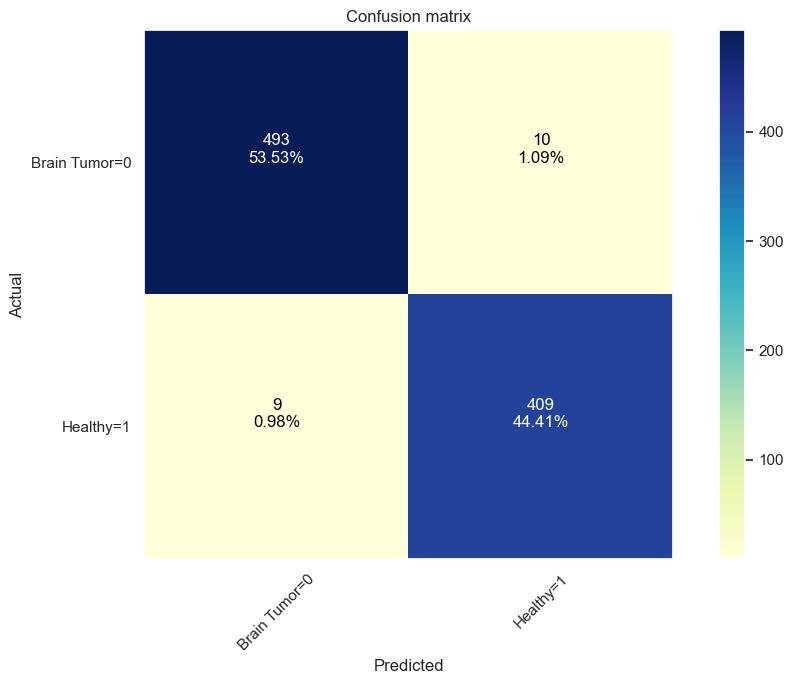

In [27]:
# Confusion Matrix Plotting Function
def show_confusion_matrix(cm, CLA_label, title='Confusion matrix', cmap=plt.cm.YlGnBu):
    
    plt.figure(figsize=(10,7))
    plt.grid(False)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(CLA_label))

    plt.xticks(tick_marks, [f"{value}={key}" for key , value in CLA_label.items()], rotation=45)
    plt.yticks(tick_marks, [f"{value}={key}" for key , value in CLA_label.items()])

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i,j]}\n{cm[i,j]/np.sum(cm)*100:.2f}%", horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

show_confusion_matrix(cm, CLA_label)

**Finding:**

The classification metrics and confusion matrix collectively confirm that the CNN model performs exceptionally well in distinguishing between brain tumor and healthy MRI images. The model achieved an overall accuracy of 98%, with precision, recall, and F1-score all at 0.98 for both classes. This reflects a highly balanced and robust classification performance, with minimal false positives and false negatives.

The confusion matrix plot further visualizes this performance:
- The model correctly predicted 493 out of 503 tumor cases and 409 out of 418 healthy cases, showing strong reliability across both categories.
- Only 10 tumor images were misclassified as healthy, and 9 healthy images were incorrectly labeled as tumors — accounting for just about 2% of the total validation set.
- These low misclassification rates are visualized in the matrix using intensity-based shading and percentage annotations, which reinforce the model’s stability and accuracy.

Together, these results highlight the CNN model’s strong ability to generalize from training data and accurately classify unseen medical images. This level of performance indicates the model is well-suited for real-world clinical decision support, particularly in the early detection of brain tumors.

### Display Correct & Incorrect Predictions <a class="anchor" id="Section_33"></a>

In [59]:
# Get predictions and labels again
y_true, y_pred = Ture_and_Pred(val_loader, cnn_model)

# Convert val_loader to a list of batches to access images
val_batches = list(val_loader)

correct_imgs = []
incorrect_imgs = []
correct_labels = []
incorrect_labels = []
predicted_labels = []
correct_pred_labels = []

# Loop through the dataset and classify each image
cnn_model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = cnn_model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            true = labels[i].item()
            pred = preds[i].item()
            img = images[i].cpu()

            if true == pred and len(correct_imgs) < 6:  # limit to 6
                correct_imgs.append(img)
                correct_labels.append(true)
                correct_pred_labels.append(pred)
                
            elif true != pred and len(incorrect_imgs) < 6:
                incorrect_imgs.append(img)
                incorrect_labels.append(true)
                predicted_labels.append(pred)

        if len(correct_imgs) >= 6 and len(incorrect_imgs) >= 6:
            break

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3611329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


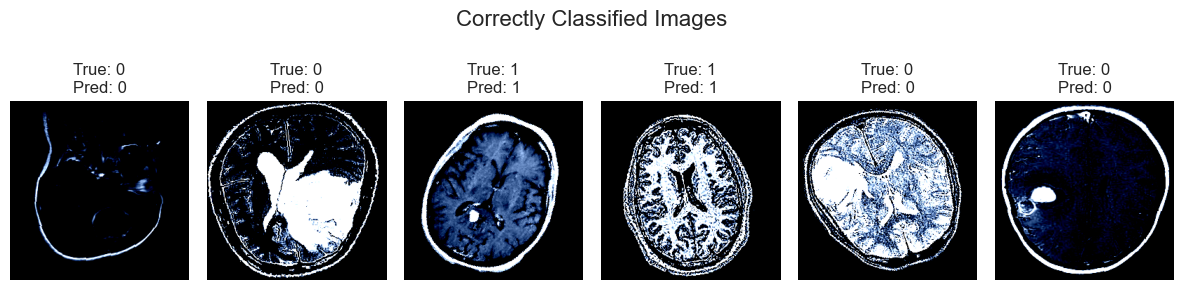

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5005665].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1171243].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5702832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3088455].


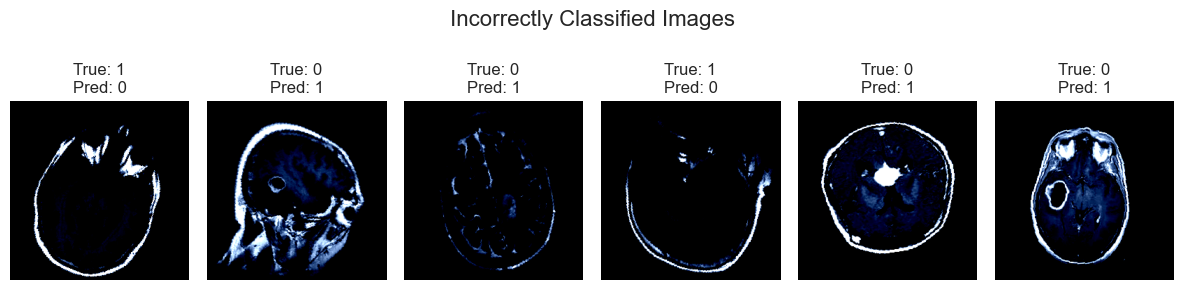

In [60]:
# Plot results
def imshow(img, title):
    img = img.permute(1, 2, 0)  # [C,H,W] to [H,W,C]
    img = img.numpy()
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

# Plot correct predictions
plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 6, i + 1)
    imshow(correct_imgs[i], f"True: {correct_labels[i]}\nPred: {correct_pred_labels[i]}")
plt.suptitle("Correctly Classified Images", fontsize=16)
plt.tight_layout()
plt.show()

# Plot incorrect predictions
plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 6, i + 1)
    imshow(incorrect_imgs[i], f"True: {incorrect_labels[i]}\nPred: {predicted_labels[i]}")
plt.suptitle("Incorrectly Classified Images", fontsize=16)
plt.tight_layout()
plt.show()

**Interpretation of True and Predicted Labels:**

To better understand model performance, we visualized examples of correctly and incorrectly classified brain MRI images. Each image is labeled with its ground truth (True: X) and the model’s prediction (Pred: Y), where:
- 0 represents brain tumor
- 1 represents healthy (no tumor)

Images labeled with True: X, Pred: X are those the model classified correctly. For instance, a label of True: 0, Pred: 0 indicates that the image indeed shows a brain tumor and the model successfully predicted it. Similarly, True: 1, Pred: 1 means the image is from a healthy scan and was correctly identified. These are displayed under the “Correctly Classified Images” section and demonstrate the model’s ability to detect both tumor presence and absence reliably.

On the other hand, the “Incorrectly Classified Images” section contains cases where the prediction did not match the ground truth. Two types of errors are visible:
- True: 0, Pred: 1 — the model failed to detect a tumor (false negative).
- True: 1, Pred: 0 — the model incorrectly flagged a healthy scan as containing a tumor (false positive).

These errors are critical to investigate, especially false negatives, as they could lead to missed diagnoses in real clinical settings. By reviewing these visual cases, we gain insight into the model’s confusion and can explore ways to improve performance — such as training with more ambiguous or borderline examples.

### Save Model <a class="anchor" id="Section_34"></a>

In [61]:
torch.save(cnn_model, "Brain_Tumor_model.pt")

### 4. Reflection <a class="anchor" id="Section_4"></a>

#### Q1. How do CNNs and other deep learning models help in detecting image anomalies? (What patterns or features might these models learn to detect that are invisible to the human eye?)

CNNs:

Convolutional Neural Networks (CNNs) are particularly effective at detecting image anomalies because they learn hierarchical features directly from raw pixel data. In early layers, CNNs identify low-level patterns such as edges, curves, and textures. As the network deepens, it captures more abstract and localized structures like shapes, lesions, or regions of abnormal brightness. These representations become increasingly complex and semantically rich, allowing CNNs to detect subtle anomalies such as irregular tissue textures, asymmetric formations, or small tumors — details that may not be apparent to the human eye due to their faintness, scale, or location. For example, in medical imaging, CNNs have shown the ability to distinguish between healthy and abnormal brain tissue based on micro-patterns in MRIs that are difficult for radiologists to catch consistently. Moreover, CNNs process visual data with high spatial precision and consistency, eliminating human variability in interpretation.

Other Deep Learning Models:

Beyond CNNs, other deep learning models such as Autoencoders, Generative Adversarial Networks (GANs), and Vision Transformers (ViTs) also contribute to anomaly detection in powerful ways. Autoencoders, which are trained to reconstruct input images, excel at detecting anomalies by measuring reconstruction error — they reconstruct normal patterns well but perform poorly when an image deviates from the learned distribution, such as in cases of fraud or rare pathologies. GANs can generate synthetic “normal” images and compare them to actual inputs to flag suspicious discrepancies, often capturing tampered or adversarial regions that mimic realism. Vision Transformers, which use self-attention mechanisms to model global image context, are especially good at detecting anomalies that break spatial or contextual coherence — for example, when an abnormal object appears in an unusual location or a subtle inconsistency exists across different image regions. These models are capable of identifying irregularities that span beyond local textures, including complex relationships and patterns that emerge across the entire image.

Comparison Between CNNs and Other Models:

While CNNs are well-suited for localized feature extraction and excel at identifying spatial anomalies through convolutional filters, other deep learning models offer complementary strengths. Autoencoders and GANs are particularly effective in unsupervised settings where labeled anomalies are rare, relying on reconstruction and generative discrepancies rather than direct classification. Transformers, on the other hand, surpass CNNs in capturing long-range dependencies and global structure — making them ideal for detecting contextual or relational anomalies. Compared to CNNs, these models may require more data and computation but can uncover deeper, less obvious irregularities. In practice, CNNs remain the go-to architecture for many anomaly detection tasks due to their efficiency and interpretability, but hybrid or ensemble approaches that combine CNNs with these newer models are increasingly adopted to achieve more robust and nuanced anomaly detection.

#### Q2. What are the potential consequences of undetected image tampering in healthcare? (How can it affect diagnosis, treatment, insurance claims, or research integrity?)

Undetected image tampering in healthcare can lead to serious and wide-ranging consequences that impact not only individual patients but also the broader medical, financial, and research systems. At the clinical level, tampered medical images — such as altered MRIs, CT scans, or X-rays — can mislead physicians into making incorrect diagnoses. For example, if a tumor is digitally removed or artificially added, it may result in a patient being wrongly diagnosed, leading to either unnecessary treatment (such as surgery or chemotherapy) or missed intervention that delays life-saving care. This undermines the core goal of medical imaging: accurate and timely diagnosis.

From a financial and legal standpoint, image tampering can distort insurance claims. Fraudulent imaging data may be used to exaggerate conditions to secure unwarranted reimbursements, or conversely, to deny coverage by removing visible evidence of illness. This not only causes financial strain on insurance systems but can also lead to ethical and legal disputes between patients, providers, and payers. Moreover, in the context of clinical research, using manipulated images in studies corrupts the integrity of findings. Fake or modified images can skew research conclusions, misguide drug development, or invalidate AI model training datasets — potentially affecting thousands of downstream applications and even leading to retractions or public mistrust in medical science.

#### Q3. What are some ethical and legal considerations when deploying AI for image fraud detection in healthcare? (Should patients be informed if an AI model suspects image tampering?)

From an ethical perspective, deploying AI for image fraud detection must prioritize patient privacy and the preservation of mutual trust between patients and healthcare providers. Patients have a right to know how their medical data is being used and should be given the option to accept or decline the use of AI-based tools in their diagnostic process. Respecting patient autonomy is essential, especially when AI is used to make judgments that could affect diagnosis or care.

Legally, healthcare organizations must ensure compliance with data protection regulations such as HIPAA in the U.S. or GDPR in the EU. This includes securing patient data, maintaining transparency in how AI decisions are made, and documenting any actions taken in response to suspected tampering. Legal frameworks also require that any AI system used in a clinical setting be properly validated and that its outputs are subject to clinical oversight.

**Yes**, patients should be informed if an AI model suspects image tampering. Even if the suspicion is not yet confirmed, informing the patient promotes transparency and reinforces trust. However, this should be done after human review to avoid causing unnecessary alarm. Ultimately, AI should support — not replace — ethical communication and shared decision-making in healthcare.

#### Q4. What are the limitations of current AI-based image fraud detection systems? (Can they be fooled? How can their reliability be improved?)

AI-based image fraud detection systems have made significant strides, but they still face notable challenges. A key vulnerability lies in **adversarial attacks**, where subtle pixel-level manipulations—often imperceptible to the human eye—can deceive models into misclassifying or overlooking tampered images. These systems typically learn from historical data, which means they may struggle to detect novel or sophisticated manipulations that deviate from known patterns.

Another limitation is the **lack of explainability** in many deep learning models. When an AI flags a legitimate image as fraudulent, clinicians and researchers may find it difficult to understand the rationale behind the decision, undermining trust in the system. Additionally, dataset bias and model overfitting can reduce generalizability, especially when models are trained on narrow or synthetic datasets.

**Strategies to Improve Reliability**

To enhance the robustness and trustworthiness of these systems, several approaches can be adopted:

- **[Human-in-the-loop frameworks](https://www.proofig.com/newsroom/how-ai-tools-are-fighting-image-fraud-in-scientific-research)**: Integrating expert validation with AI predictions helps reduce false positives and ensures more reliable decision-making.
- **[Multi-model ensembles](https://eudl.eu/pdf/10.4108/eai.23-11-2023.2343170)**: Combining architectures such as CNNs, transformers, and autoencoders allows systems to detect both local pixel anomalies and broader contextual inconsistencies.
- **[Feature pruning and attention head analysis](https://scisimple.com/en/articles/2025-07-25-improving-detection-of-ai-generated-images--aky7nql)**: Removing misleading features and focusing on key outputs from models like CLIP can significantly boost cross-generator detection accuracy.